# Set up the Environment

In [1]:
!pip install tensorflow

In [2]:
# Import Necessary Libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import layers, models, utils, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset

In [3]:
# Load and Explore the Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
print("The number of training examples is:", X_train.shape[0])
print("The number of test examples is:", X_test.shape[0])
print("The size of every image is:", X_train.shape[1:])
num_classes = len(np.unique(y_train))
print("The number of classes is:", num_classes)
print("The type of the training images is: ", X_train.dtype)

The number of training examples is: 60000
The number of test examples is: 10000
The size of every image is: (28, 28)
The number of classes is: 10
The type of the training images is:  uint8


Text(0.5, 1.0, 'Ground truth is: 4')

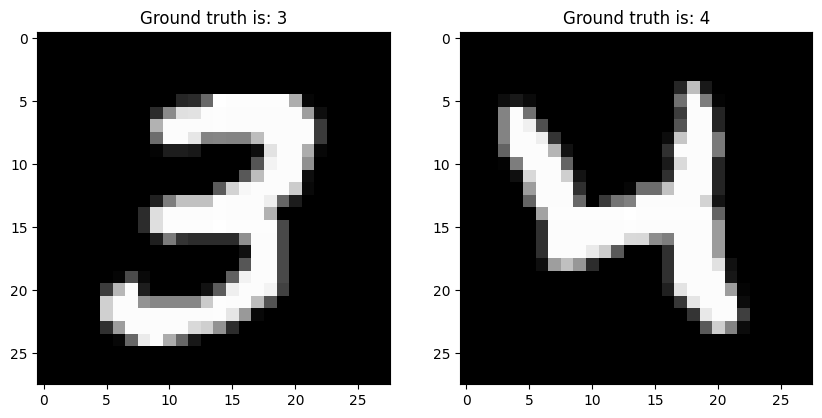

In [5]:
# Printing out some sample images from the training set
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.imshow(X_train[7], cmap='gray')
ax1.set_title("Ground truth is: {}".format(y_train[7]))

ax2.imshow(X_train[20], cmap='gray')
ax2.set_title("Ground truth is: {}".format(y_train[20]))

# Preprocess the Data

In [6]:
# Reshape to add channel dimension (grayscale)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert to float and normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the CNN Model

In [7]:
# Create a custom CNN model
model = models.Sequential([
    # First Conv2D layer
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # Max pooling to reduce spatial dimensions

    # Second Conv2D layer
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # Max pooling layer

    # Third Conv2D layer
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # Max pooling layer

    # Flatten the feature maps for the fully connected layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),

    # Fully connected layer
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),

    # Dropout layer to reduce overfitting
    layers.Dropout(0.5),

    # Output layer for 10 classes (softmax for multi-class classification)
    layers.Dense(10, activation='softmax')
])

# Compile the Model

In [8]:
# Add learning rate scheduler and early stopping
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-4 * 0.9 ** epoch)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

In [9]:
# Recompile and fit the model with the changes
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Print model summary to verify architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,922 (1.61 MB)

 Trainable params: 422,474 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

# Train the Model

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_schedule, early_stopping],
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 118s 130ms/step - accuracy: 0.5595 - loss: 6.7385 - val_accuracy: 0.9745 - val_loss: 3.5772 - learning_rate: 1.0000e-04
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 131s 155ms/step - accuracy: 0.9319 - loss: 3.3273 - val_accuracy: 0.9862 - val_loss: 2.1557 - learning_rate: 9.0000e-05
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 133s 144ms/step - accuracy: 0.9648 - loss: 2.0100 - val_accuracy: 0.9867 - val_loss: 1.3402 - learning_rate: 8.1000e-05
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 108s 128ms/step - accuracy: 0.9738 - loss: 1.2622 - val_accuracy: 0.9893 - val_loss: 0.8521 - learning_rate: 7.2900e-05
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 145s 131ms/step - accuracy: 0.9801 - loss: 0.8132 - val_accuracy: 0.9907 - val_loss: 0.5586 - learning_rate: 6.5610e-05
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 143s 132ms/step - accuracy: 0.9838 - loss: 0.5420 - val_accuracy: 0.9897 - val_loss: 0.3837 - learning_rate: 5.9049e-05
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 

# Evaluate the Model

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test,verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.1412
Test Accuracy: 0.9919


# Visualize Accuracy and Loss Curves

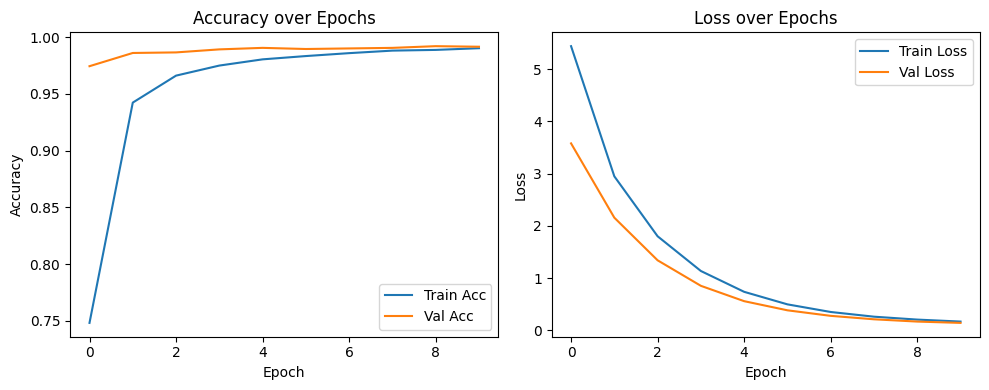

In [13]:
plt.figure(figsize=(10,4))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# MNIST Digit Classification: Prediction vs Actual Label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


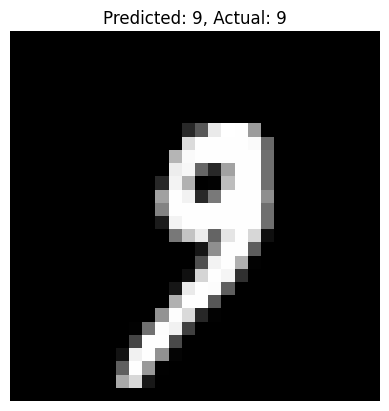

Prediction is correct! Predicted class: 9, Actual class: 9


In [14]:
# Select the 1000th image
image_index = 1000
image = X_test[image_index].reshape(28, 28)  # No need for ':' if already 2D

# Predict the class for the image
predicted_class = np.argmax(model.predict(X_test[[image_index]]))

# Get the actual label for the image
# y_test is one-hot encoded, get the index of the true class
actual_label = np.argmax(y_test[image_index])

# Plot the input image
plt.imshow(image, cmap='gray')
plt.title(f'Predicted: {predicted_class}, Actual: {actual_label}')
plt.axis('off')
plt.show()

# Check if the prediction matches the actual label
if predicted_class == actual_label:
    print(f"Prediction is correct! Predicted class: {predicted_class}, Actual class: {actual_label}")
else:
    print(f"Prediction is incorrect. Predicted class: {predicted_class}, Actual class: {actual_label}")